In [1]:

# Ensure repo on sys.path (works when run from CLI or inside the notebook directory)
import sys
from pathlib import Path

# Start from CWD; if __file__ defined (exported), use that
repo_root = Path.cwd()
if '__file__' in globals():
    repo_root = Path(__file__).resolve().parents[2]

# Climb parents until we find the top-level nevermore/configs marker
marker = Path('nevermore/configs/default.yaml')
for parent in [repo_root] + list(repo_root.parents):
    if (parent / marker).exists():
        repo_root = parent
        break

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print('Repo root1:', repo_root)


Repo root1: /scratch/home/sr3622/Firm-DTI/Firm-DTI2


In [ ]:
import copy
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from nevermore.pipeline import NevermorePipeline, load_config

repo_root = Path("/scratch/home/sr3622/Firm-DTI/Firm-DTI2")
data_dir = repo_root / "data"
train = pd.read_csv(data_dir / "train.csv")

admet_cols = ["molecular_weight", "logP", "HIA_Hou", "hERG", "QED", "Lipinski"]
run_name_prefix = "check_beta_"

base_cfg = load_config(repo_root / "nevermore" / "configs" / "default.yaml")
base_cfg.docking.enabled = False
base_cfg.visualization.enabled = False

results = []
for i, row in tqdm(train.iloc[:10].iterrows(), total=10):
    target = row["Target"]
    drug_train = row["Drug"]
    y_train = row["Y"]  # actual label

    cfg = copy.deepcopy(base_cfg)
    cfg.optimization.target_sequence = target
    cfg.optimization.baseline_smiles = drug_train

    pipe = NevermorePipeline(config=cfg)
    res = pipe.run(up_to="report", verbose=True)

    opt_details = res["optimization"].details
    baseline_aff = opt_details.get("baseline_affinity")
    optimized_aff = opt_details.get("optimized_affinity")
    delta_aff = optimized_aff - baseline_aff if baseline_aff is not None and optimized_aff is not None else np.nan

    rep_df = pd.read_csv(res["report"].outputs["report"])
    admet_present = [c for c in admet_cols if c in rep_df.columns]
    admet_mean = rep_df[admet_present].mean() if admet_present else pd.Series(dtype=float)
    admet_std = rep_df[admet_present].std() if admet_present else pd.Series(dtype=float)
    pred_aff_mean = rep_df["predicted_affinity"].mean() if "predicted_affinity" in rep_df.columns else np.nan
    pred_aff_std = rep_df["predicted_affinity"].std() if "predicted_affinity" in rep_df.columns else np.nan

    row_out = {
        "run_name": cfg.run_name,
        "target": target,
        "drug_train": drug_train,
        "Y_train": y_train,
        "baseline_affinity": baseline_aff,
        "optimized_affinity": optimized_aff,
        "delta_affinity": delta_aff,
        "pred_aff_mean": pred_aff_mean,
        "pred_aff_std": pred_aff_std,
    }
    for c in admet_present:
        row_out[f"{c}_mean"] = admet_mean[c]
        row_out[f"{c}_std"] = admet_std[c]

    results.append(row_out)

results_df = pd.DataFrame(results)
out_path = repo_root / "results3" / f"{run_name_prefix}summary.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(out_path, index=False)
print("Saved results to", out_path)


In [ ]:
import pandas as pd
from pathlib import Path

results_dir = Path("/scratch/home/sr3622/Firm-DTI/Firm-DTI2/results3")  # adjust if needed
rows = []
for csv_path in results_dir.glob("*.csv"):
    df = pd.read_csv(csv_path)
    mean_vals = df.mean(numeric_only=True)
    rows.append({"file": csv_path.name, **mean_vals.to_dict()})

summary = pd.DataFrame(rows)

display(summary)

# # optionally save
out_path =  "combined_summary1.csv"
summary.to_csv(out_path, index=False)
# print("Saved to", out_path)


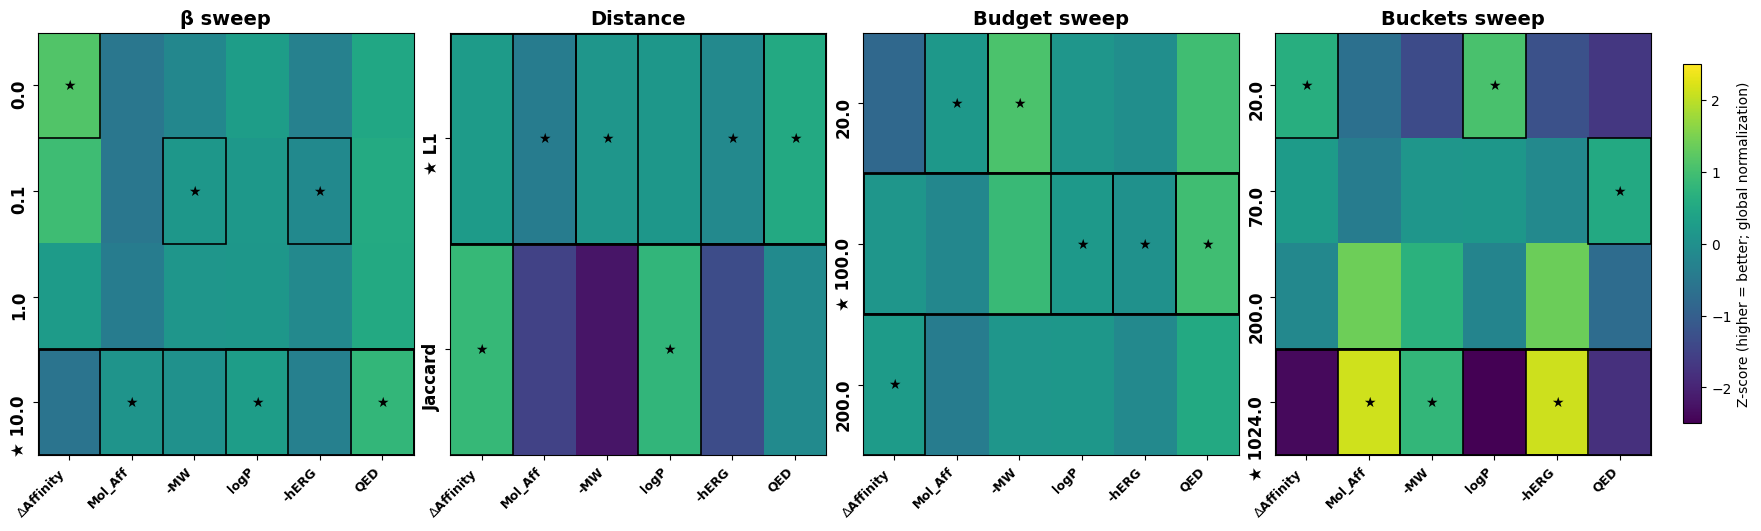

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.cluster.hierarchy import linkage, dendrogram

df = pd.read_csv("combined_summary.csv")
df["num"] = df["file"].str.extract(r"(\d+)").astype(int)
df.sort_values("num", inplace=True)

runs = df.iloc[:11].copy()
runs["run_id"] = runs["num"]  # FIX: use runs not df

beta_map   = {7: 0,   2: 1,   5 : 0.1, 6: 10}
dist_map   = {8: "Jaccard", 2: "L1"}
budget_map = {10: 100, 2: 200, 9: 20 }
bucket_map = {1: 20,  2: 70, 3: 200, 4: 1024}

runs["beta"] = runs["run_id"].map(beta_map)
runs["distance"] = runs["run_id"].map(dist_map)
runs["budget"] = runs["run_id"].map(budget_map)
runs["buckets"] = runs["run_id"].map(bucket_map)

metric_cols   = ["delta_affinity","pred_aff_mean","molecular_weight_mean","logP_mean","hERG_mean","QED_mean"]
metric_labels = [r"$\Delta$Affinity", r"Mol_Aff", "-MW", "logP", r"-hERG", "QED"]

X = runs[metric_cols].astype(float).copy()
X["hERG_mean"] *= -1
X["molecular_weight_mean"] *= -1


Z = X.copy()
for c in Z.columns:
    mu = Z[c].mean()
    sd = Z[c].std(ddof=0)
    Z[c] = (Z[c] - mu) / (sd if sd > 1e-12 else 1.0)

def cluster_order(Zsub: np.ndarray):
    if Zsub.shape[0] <= 2:
        return list(range(Zsub.shape[0]))
    L = linkage(Zsub, method="average", metric="euclidean")
    return dendrogram(L, no_plot=True)["leaves"]

panels = [
    ("β sweep",       [7,5,2,6],      "beta"),
    ("Distance",      [8,2],            "distance"),
    ("Budget sweep",  [9,10,2],      "budget"),
    ("Buckets sweep", [1,2,3,4],    "buckets"),
]

vmin, vmax = -2.5, 2.5
fig, axes = plt.subplots(1, 4, figsize=(17.5, 5.2), constrained_layout=True)

RTOL, ATOL = 1e-9, 1e-12

for ax, (title, ids, param) in zip(axes, panels):
    sub = runs[runs["run_id"].isin(ids)].copy()
    Zsub_df = Z.loc[sub.index].copy()

    # ---- ROW ORDER CONTROL ----
    if title == "β sweep":
        # Order explicitly by beta value (ascending)
        sub = sub.sort_values("beta", kind="stable")
        Zsub_df = Zsub_df.loc[sub.index]
    else:
        # Keep clustering for other panels
        Zsub = Zsub_df.values
        order = cluster_order(Zsub)
        sub = sub.iloc[order]
        Zsub_df = Zsub_df.iloc[order]

    if title == "Budget sweep":
        # Order explicitly by beta value (ascending)
        sub = sub.sort_values("budget", kind="stable")
        Zsub_df = Zsub_df.loc[sub.index]

    
    if title == "Buckets sweep":
        # Order explicitly by beta value (ascending)
        sub = sub.sort_values("buckets", kind="stable")
        Zsub_df = Zsub_df.loc[sub.index]

    sub = sub.reset_index(drop=True)
    Zsub_df = Zsub_df.reset_index(drop=True)
    Zsub = Zsub_df.values

    # Best overall row = column-wins (vote), tie-break by mean z
    best_per_col = np.argmax(Zsub, axis=0)
    votes = np.bincount(best_per_col, minlength=Zsub.shape[0])
    mean_z = Zsub.mean(axis=1)
    winners = np.where(votes == votes.max())[0]
    best_row = int(winners[np.argmax(mean_z[winners])])

    im = ax.imshow(Zsub, aspect="auto", interpolation="nearest", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=14,fontweight="bold")
    ax.set_xticks(np.arange(len(metric_labels)))
    ax.set_xticklabels(metric_labels, rotation=45, ha="right", fontsize=9,fontweight="bold")

    # y labels
    ylab = []
    for i, r in sub.iterrows():
        v = r[param]
        base = f"{v}" if pd.notna(v) and v != "" else f"run {int(r['run_id'])}"
        if i == best_row:
            base = "★ " + base
        ylab.append(base)
    ax.set_yticks(np.arange(len(ylab)))
    ax.set_yticklabels(ylab, fontsize=12,fontweight="bold",rotation=90,)

    # Star ALL ties per column
    for j in range(Zsub.shape[1]):
        col = Zsub[:, j]
        m = np.max(col)
        tie_rows = np.where(np.isclose(col, m, rtol=RTOL, atol=ATOL))[0]
        for i in tie_rows:
            ax.text(j, i, "★", ha="center", va="center", fontsize=10, fontweight="bold",)
            ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, linewidth=1.2))

    ax.add_patch(Rectangle((-0.5, best_row - 0.5), len(metric_cols), 1, fill=False, linewidth=2.0))

cbar = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.02)
cbar.set_label("Z-score (higher = better; global normalization)")
plt.show()


out_png = "../../results/images/sweep_cluster_heatmaps_starred.png"
out_pdf = "../../results/images/sweep_cluster_heatmaps_starred.pdf"
fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.close(fig)
